# 05. PySATL CPD API: Reset Benchmarking

## Section 1. Orientation

The online notebook showed how one reset detector behaves on one provider. The next problem is comparative evaluation: how do we judge several reset detector configurations systematically over a dataset rather than by eye on one trace? That is the job of reset benchmarking.

Reset benchmarking is built around the idea that a detector run is a whole-timeseries event sequence. Once a change point is declared, the detector resets and begins learning again. That semantics is what makes the metric families in this notebook different from the transition-centered no-reset story that follows later.


## What in this notebook

By the end of the notebook, you should know how to build a threshold sweep of reset detectors, register them as benchmark entries, evaluate multiple-run classification and delay metrics, merge those metric outputs into one benchmark-ready table, and connect one chosen operating point back to a concrete trace on one provider.

The notebook assumes you already know the basic provider, detector, and plotter abstractions from the earlier chapters. The focus here is on reset-specific evaluation logic and on the shape of the current reset benchmark API.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from plotly.subplots import make_subplots

from pysatl_cpd.algorithms.online import ShewhartControlChart
from pysatl_cpd.analysis.metrics.multiple_run.classification import ClassificationReport
from pysatl_cpd.analysis.metrics.multiple_run.online import ARLMetric, MeanDelayMetric, MedianDelayMetric
from pysatl_cpd.analysis.visualization import DrawBackend, OnlineCpdPlotter
from pysatl_cpd.analysis.visualization.benchmarking import (
    BenchmarkPlotter,
    ThresholdBasedMetricVisualizer,
)
from pysatl_cpd.benchmark.online.reset import OnlineResetBenchmark, OnlineResetBenchmarkEntry
from pysatl_cpd.benchmark.registry import BenchmarkRegistry
from pysatl_cpd.core.online import OnlineResetDetector
from pysatl_cpd.data.generator import preset_dataset
from pysatl_cpd.data.providers.transformers import ColumnsSelectorTransformer

## Section 2. Building a Reset Benchmark Campaign

The first benchmarking problem is campaign design: which data, which detector family, and which parameter sweep are we actually evaluating? A tutorial campaign should be small enough to run quickly but large enough to make the metrics and plots meaningful.

In this chapter, we use a preset mean-shift dataset and sweep one Shewhart reset detector across several thresholds. That is enough to expose the structure of the reset benchmark API without drowning the notebook in configuration noise.


### 2.1 Choosing the dataset and feature view

Even in a simple tutorial, it helps to be explicit about what the detector is observing. A preset dataset gives us labeled providers immediately, while a feature transformer makes it clear which column the univariate detector will actually consume.

The reset benchmark API does not require feature transformation, but in multivariate preset datasets it is often the clearest way to define the detector input space.


In [2]:
FEATURE = "feature_0"
THRESHOLDS = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
ERROR_MARGIN = (0, 15)
MAX_DELAY = ERROR_MARGIN[1]

dataset = preset_dataset("extreme_mean_shifts", n_series=100, seed=7, series_length=500)
feature_transformer = ColumnsSelectorTransformer(columns=[FEATURE])

print("Dataset size:", len(dataset))
print("Provider names:", [provider.annotation.name for provider in dataset[:3]])
print("Dataset transitions:", [repr(transition) for transition in dataset.transitions])
print("Selected feature transformer annotation:", feature_transformer.annotation)

Dataset size: 100
Provider names: ['extreme_mean_shifts_series_0000', 'extreme_mean_shifts_series_0001', 'extreme_mean_shifts_series_0002']
Dataset transitions: ["type='extreme_high'->type='extreme_low'", "type='baseline'->type='extreme_high'"]
Selected feature transformer annotation: column[feature_0]


### 2.2 Configuring reset detectors

The second problem is defining the family of detectors we want to compare. In a reset benchmark, the most common first sweep is threshold tuning: keep the algorithm and skip-period logic fixed, vary the threshold, and examine how the event sequence changes.

The API makes that explicit. Each `OnlineResetDetector` is already a fully configured detector, not just an algorithm plus a threshold value stored somewhere else.


In [3]:
entries = []
for threshold in THRESHOLDS:
    detector = OnlineResetDetector(
        ShewhartControlChart(learning_period_size=100, window_size=10),
        threshold=threshold,
        skip_period=5,
        collect_states=False,
        data_transformer=feature_transformer,
    )
    entries.append(OnlineResetBenchmarkEntry(detector=detector))

print("Number of benchmark entries:", len(entries))
for entry in entries:
    print(entry.description)

Number of benchmark entries: 14
ChangePointDetectorDescription(name='online_reset_detector', parameters=frozendict({'algorithm': OnlineAlgorithmDescription(name='ShewhartControlChart', configuration=w = 10), 'threshold': 0.5, 'skip_period': 5, 'max_runlength': None, 'collect_states': False, 'data_transformer': 'column[feature_0]'}))
ChangePointDetectorDescription(name='online_reset_detector', parameters=frozendict({'algorithm': OnlineAlgorithmDescription(name='ShewhartControlChart', configuration=w = 10), 'threshold': 1.0, 'skip_period': 5, 'max_runlength': None, 'collect_states': False, 'data_transformer': 'column[feature_0]'}))
ChangePointDetectorDescription(name='online_reset_detector', parameters=frozendict({'algorithm': OnlineAlgorithmDescription(name='ShewhartControlChart', configuration=w = 10), 'threshold': 1.5, 'skip_period': 5, 'max_runlength': None, 'collect_states': False, 'data_transformer': 'column[feature_0]'}))
ChangePointDetectorDescription(name='online_reset_detector'

### 2.3 Why entries wrap complete detectors

A benchmark entry could, in principle, have been designed as an algorithm plus a free-floating threshold. The current reset API instead chooses to wrap a fully configured detector. That is an important design decision because it keeps the runtime contract intact all the way into the benchmark layer.

In practice, that means benchmark descriptions remain faithful to real detector configurations. If a detector differs by threshold, skip period, or transformer, that difference is already part of the detector description stored in the benchmark entry.


In [4]:
print("One concrete detector description:")
print(entries[0].detector.description)

One concrete detector description:
ChangePointDetectorDescription(name='online_reset_detector', parameters=frozendict({'algorithm': OnlineAlgorithmDescription(name='ShewhartControlChart', configuration=w = 10), 'threshold': 0.5, 'skip_period': 5, 'max_runlength': None, 'collect_states': False, 'data_transformer': 'column[feature_0]'}))


**Summary of Section 2:** A reset benchmark campaign is built from a labeled dataset, a feature view, and a family of fully configured reset detectors. In the current API, those configured detectors are wrapped inside `OnlineResetBenchmarkEntry` objects before benchmarking begins.


## Section 3. Registry and Benchmark Orchestration

Once the campaign exists, the next problem is execution management. Running the same detector-provider combinations repeatedly for every metric family would be wasteful and would also blur the conceptual line between “detector execution” and “metric aggregation.”

The reset benchmark API solves that problem with two coordinating objects: a registry that caches single runs and a benchmark object that asks for metrics over a collection of entries.


### 3.1 BenchmarkRegistry

The registry exists to remember completed detector runs keyed by detector and provider descriptions. That way, once a run exists, several metrics can reuse it without re-executing the detector unnecessarily.

This is important conceptually as well as computationally. It means the benchmark layer treats “run the detector” and “score the result” as separate steps, which keeps the architecture easier to understand.


In [5]:
registry = BenchmarkRegistry()
print("Registry size before benchmarking:", len(registry))

Registry size before benchmarking: 0


### 3.2 OnlineResetBenchmark

The benchmark object is the orchestrator that binds a dataset and a registry together. It knows how to take a set of entries and a multiple-run metric, execute the necessary detector runs if they are missing, and return a metric result keyed by detector description.

The key public method is `get_metrics_for(...)`. The benchmark itself does not hardcode one metric family; it delegates to metric objects supplied by the caller.


In [6]:
benchmark = OnlineResetBenchmark(dataset=dataset, registry=registry)
print("Benchmark created with dataset size:", len(dataset))
print("Registry object attached:", isinstance(benchmark._registry, BenchmarkRegistry))

Benchmark created with dataset size: 100
Registry object attached: True


### 3.3 Why orchestration is separate from metrics

A metric should describe how to aggregate already-available runs, not how to schedule detector execution. Separating the benchmark object from the metric objects keeps those responsibilities distinct and makes the reset benchmark API easier to extend.

This matters later when we combine several metric families. The benchmark orchestration stays the same even though the interpretation of the resulting runs changes from classification counts to delays or ARL.


In [7]:
print("Benchmark method used throughout this chapter:", OnlineResetBenchmark.get_metrics_for.__name__)

Benchmark method used throughout this chapter: get_metrics_for


**Summary of Section 3:** The reset benchmark stack separates execution management from scoring. `BenchmarkRegistry` caches detector runs, while `OnlineResetBenchmark` orchestrates metric evaluation over a set of entries and one shared dataset.


## Section 4. Metric Families for Reset Evaluation

With orchestration in place, the next problem is meaning: what exactly do we want to measure about the reset detector runs? In reset mode, the natural emphasis is whole-timeseries event sequences rather than transition-local behavior.

This section introduces the three metric families used in the notebook: classification metrics, delay metrics, and average run length. Each family answers a different operational question about the same detector runs.


### 4.1 Classification metrics

The motivation for classification metrics is to answer the basic event-detection question: how many declared detections matched true change points well enough to count as correct, and how many did not? Precision, recall, and F1 summarize that behavior more compactly than raw TP, FP, and FN counts alone.

In the current reset API, `ClassificationReport` is the main metric object for that purpose. It aggregates several underlying multiple-run classification metrics and returns a dictionary of the resulting scores.


In [8]:
classification_metric = ClassificationReport(error_margin=ERROR_MARGIN)
print("Classification metric object:", classification_metric)

Classification metric object: <pysatl_cpd.analysis.metrics.multiple_run.classification.report.ClassificationReport object at 0x7f3b678446e0>


### 4.2 Delay metrics

A detector can be correct but still not timely. The next problem is measuring how long the detector waited after a true change before responding. That is what the delay metrics summarize.

`MeanDelayMetric` and `MedianDelayMetric` take a `max_delay` parameter that caps empty or overly long delays. This keeps the metric behavior well-defined even when detections are sparse or missing.


In [9]:
mean_delay_metric = MeanDelayMetric(max_delay=MAX_DELAY)
median_delay_metric = MedianDelayMetric(max_delay=MAX_DELAY)
print("Mean delay metric:", mean_delay_metric)
print("Median delay metric:", median_delay_metric)

Mean delay metric: <pysatl_cpd.analysis.metrics.multiple_run.online.delay.MeanDelayMetric object at 0x7f3b67845400>
Median delay metric: <pysatl_cpd.analysis.metrics.multiple_run.online.delay.MedianDelayMetric object at 0x7f3b678456a0>


### 4.3 Average run length

The final problem is false-alarm robustness across runs. In reset mode, one useful summary is average run length: how long the detector tends to go before producing an alarm. This complements classification and delay by focusing more on alarm frequency than on matching quality.

`ARLMetric` is the current multiple-run metric for that purpose. In a threshold sweep, it often reveals a tradeoff against recall or responsiveness.


In [10]:
arl_metric = ARLMetric()
print("ARL metric:", arl_metric)

ARL metric: <pysatl_cpd.analysis.metrics.multiple_run.online.arl.ARLMetric object at 0x7f3b678457f0>


**Summary of Section 4:** Reset evaluation uses several metric families because no single summary captures the whole detector story. Classification metrics describe correctness, delay metrics describe timeliness, and ARL describes alarm frequency or robustness.


## Section 5. Running Metric Scenarios and Building a Benchmark Table

The benchmark object returns one metric family at a time, but practical analysis usually needs a single table that combines several families. The next problem is therefore table construction: how do we merge reset benchmark outputs into one threshold-indexed result table suitable for inspection and plotting?

That table-building step is not busywork. It is the bridge between raw metric dictionaries and the visualizers used later in the notebook.


### 5.1 Running the benchmark for several metric families

The benchmark orchestration stays fixed while only the metric object changes. That makes the code a good demonstration of the benchmark API’s separation between execution scheduling and scoring semantics.

We run classification, mean delay, median delay, and ARL over the same entry family. Thanks to the shared registry, these metric calls can reuse detector executions instead of rerunning everything from scratch each time.


In [11]:
%%capture benchmark_run_output
classification_results = benchmark.get_metrics_for(entries, classification_metric)
mean_delay_results = benchmark.get_metrics_for(entries, mean_delay_metric)
median_delay_results = benchmark.get_metrics_for(entries, median_delay_metric)
arl_results = benchmark.get_metrics_for(entries, arl_metric)

In [12]:
print("Registry size after metric evaluation:", len(registry))
print("Number of classified detector descriptions:", len(classification_results))

Registry size after metric evaluation: 1400
Number of classified detector descriptions: 14


### 5.2 Merging the metric outputs into one table

The benchmark API deliberately returns dictionaries keyed by detector description because that is the most faithful representation of the underlying run collection. For plotting and quick inspection, though, we usually want one row per detector configuration.

The code below performs that merge explicitly. The threshold is recovered from the detector description so the result table is immediately usable for threshold-oriented plots.


In [13]:
rows = []
for description, report in classification_results.items():
    rows.append(
        {
            "threshold": float(description.parameters["threshold"]),
            **report,
            "mean_delay": float(mean_delay_results[description]),
            "median_delay": float(median_delay_results[description]),
            "arl": float(arl_results[description]),
        }
    )

reset_table = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)
display(reset_table.round(3))

,threshold,tp,fp,fn,precision,recall,f1,mean_delay,median_delay,arl
0,0.5,0,400,200,0.000,0.000,0.000,15.000,15.0,105.120
1,1.0,21,378,179,0.053,0.105,0.070,13.575,15.0,108.870
2,1.5,59,325,141,0.154,0.295,0.202,11.185,15.0,115.281
3,2.0,93,213,107,0.304,0.465,0.368,9.215,15.0,130.739
4,2.5,150,92,50,0.620,0.750,0.679,5.410,2.0,151.525
5,3.0,187,22,13,0.895,0.935,0.914,3.220,2.0,163.895
6,3.5,199,3,1,0.985,0.995,0.990,2.790,3.0,167.243
7,4.0,200,0,0,1.000,1.000,1.000,3.150,3.0,168.285
8,4.5,200,0,0,1.000,1.000,1.000,3.565,3.0,168.480
9,5.0,200,0,0,1.000,1.000,1.000,4.010,4.0,168.655


### 5.3 Reading the reset table

A table is only useful if we know how to read it. In a reset threshold sweep, increasing the threshold often reduces false alarms and can improve precision, but it may also lower recall or alter the delay profile.

The table below is therefore not just a storage format. It is the central object that reveals how the detector’s operating point changes across the threshold sweep.


In [14]:
display(reset_table[["threshold", "precision", "recall", "f1", "mean_delay", "median_delay", "arl"]].round(3))

,threshold,precision,recall,f1,mean_delay,median_delay,arl
0,0.5,0.000,0.000,0.000,15.000,15.0,105.120
1,1.0,0.053,0.105,0.070,13.575,15.0,108.870
2,1.5,0.154,0.295,0.202,11.185,15.0,115.281
3,2.0,0.304,0.465,0.368,9.215,15.0,130.739
4,2.5,0.620,0.750,0.679,5.410,2.0,151.525
5,3.0,0.895,0.935,0.914,3.220,2.0,163.895
6,3.5,0.985,0.995,0.990,2.790,3.0,167.243
7,4.0,1.000,1.000,1.000,3.150,3.0,168.285
8,4.5,1.000,1.000,1.000,3.565,3.0,168.480
9,5.0,1.000,1.000,1.000,4.010,4.0,168.655


**Summary of Section 5:** Reset benchmark outputs become most useful once merged into one threshold-indexed table. That table is the handoff point between metric computation and visual or comparative interpretation.


## Section 6. Visualizing Reset Benchmark Results

Once the reset table exists, the next problem is summary. Threshold sweeps are difficult to compare by reading a raw table alone, especially when several metric columns move at once. This is where the benchmark visualization layer becomes useful again.

The plotting section in this notebook does not re-teach the visualization API from first principles. Instead, it applies the visualizer patterns from notebook 04 to a real reset benchmark table.


### 6.1 Reset benchmark plots in matplotlib

The matplotlib figure below is designed as a compact operating-point dashboard. It mirrors the structure used in earlier visualization examples, but now the inputs come from a real reset benchmark run.

The `BenchmarkPlotter` coordinates four metric views here: F1, precision-recall threshold curves, delay curves, and ARL. That combination gives a good first read of the threshold sweep.

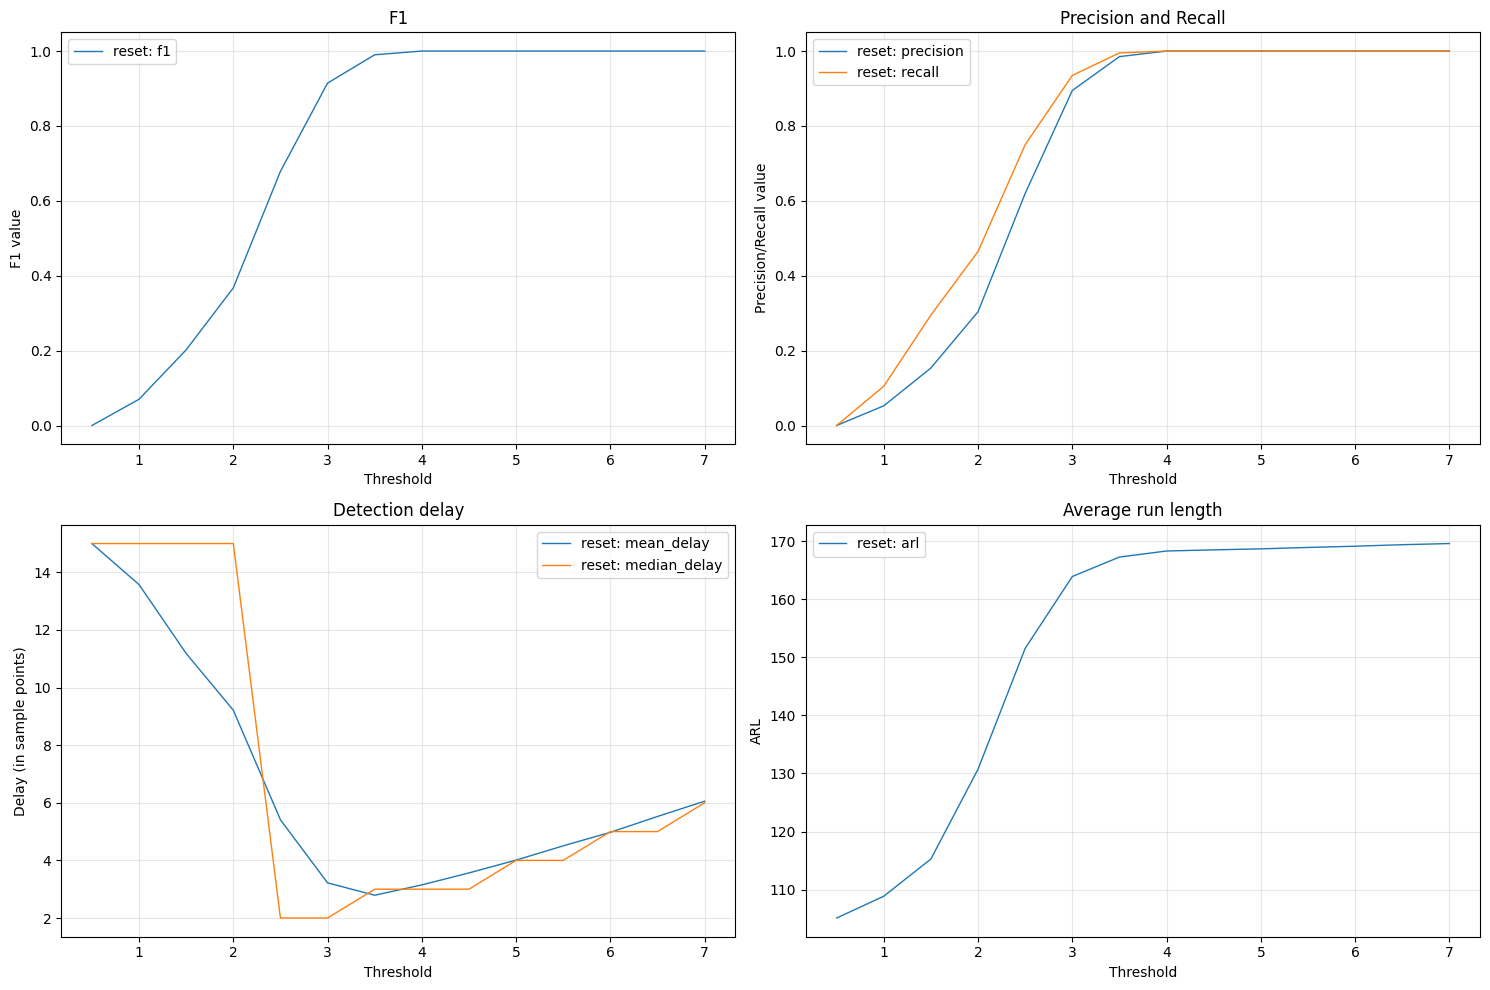

In [15]:
plotter = (
    BenchmarkPlotter()
    .set_metrics(
        {
            "f1_plot": ThresholdBasedMetricVisualizer(y_metrics=["f1"], title="F1", ylabel="F1 value"),
            "precision_recall_plot": ThresholdBasedMetricVisualizer(
                y_metrics=["precision", "recall"],
                title="Precision and Recall",
                ylabel="Precision/Recall value",
            ),
            "delay_plot": ThresholdBasedMetricVisualizer(
                y_metrics=["mean_delay", "median_delay"],
                title="Detection delay",
                ylabel="Delay (in sample points)",
            ),
            "arl_plot": ThresholdBasedMetricVisualizer(y_metrics=["arl"], title="Average run length", ylabel="ARL"),
        }
    )
    .set_benchmark_tables({"reset": reset_table})
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plotter.draw(
    figure=fig,
    axes={
        "f1_plot": axes[0, 0],
        "precision_recall_plot": axes[0, 1],
        "delay_plot": axes[1, 0],
        "arl_plot": axes[1, 1],
    },
)
plt.tight_layout()

### 6.2 Reset benchmark plots in plotly

The same operating-point dashboard is also useful in plotly when interactive inspection is desirable. This plot is the plotly twin of the previous matplotlib figure, not a different analytical message.

Showing both backends makes the plotting layer feel less like a special-case utility and more like a reusable reporting interface that can adapt to the user’s preferred output medium.


In [16]:
plotter_plotly = (
    BenchmarkPlotter()
    .set_metrics(
        {
            "f1_plot": ThresholdBasedMetricVisualizer(
                y_metrics=["f1"], title="F1", ylabel="F1 value", backend="plotly"
            ),
            "precision_recall_plot": ThresholdBasedMetricVisualizer(
                backend="plotly",
                y_metrics=["precision", "recall"],
                title="Precision and Recall",
                ylabel="Precision/Recall value",
            ),
            "delay_plot": ThresholdBasedMetricVisualizer(
                backend="plotly",
                y_metrics=["mean_delay", "median_delay"],
                title="Detection delay",
                ylabel="Delay (in sample points)",
            ),
            "arl_plot": ThresholdBasedMetricVisualizer(
                backend="plotly",
                y_metrics=["arl"],
                title="Average run length",
                ylabel="ARL",
            ),
        }
    )
    .set_benchmark_tables({"reset": reset_table})
)
plotter_plotly.backend = "plotly"

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=("F1", "Precision and Recall", "Detection delay", "Average run length"),
)
fig = plotter_plotly.draw(
    figure=fig,
    axes={
        "f1_plot": (1, 1),
        "precision_recall_plot": (1, 2),
        "delay_plot": (2, 1),
        "arl_plot": (2, 2),
    },
)
fig.update_layout(height=800, width=1200, title_text="Reset benchmark metrics (plotly)")

### 6.3 Interpreting the plotted tradeoffs

Plots are only useful if they sharpen interpretation. In a reset threshold sweep, a rising threshold usually trades sensitivity for robustness, but the exact tradeoff depends on the algorithm, skip-period logic, and dataset family.

The code below highlights one simple summary: the threshold with the highest F1 score. That value is not always the “best” operating point in practice, but it is a clear anchor for the trace-level inspection that follows.


In [17]:
best_row = reset_table.sort_values(["f1", "precision", "recall"], ascending=False).iloc[0]
display(best_row.to_frame(name="best_row"))

,best_row
threshold,4.000
tp,200.000
fp,0.000
fn,0.000
precision,1.000
recall,1.000
f1,1.000
mean_delay,3.150
median_delay,3.000
arl,168.285


**Summary of Section 6:** Reset benchmark plots compress the threshold sweep into a small number of interpretable views. The table is still the source of truth, but the figures make the operating-point tradeoffs much easier to see and discuss.


## Section 7. Explaining a Metric With One Concrete Trace

A threshold sweep tells us which operating point looks strong globally, but it does not by itself explain why. The final practical problem in this notebook is therefore local interpretation: how do we connect the winning threshold back to one real detector run?

This is where the earlier online and visualization notebooks come back into the story. We pick one detector configuration from the sweep, run it on one provider with state collection enabled, and inspect the resulting trace.


### 7.1 Picking the winning threshold

A single best row makes the later trace discussion concrete. The goal is not to claim that F1 is always the right selection criterion, only to choose one threshold from the sweep using a transparent rule.

The code below uses the highest-F1 row as the anchor point for local inspection. That makes the later explanation directly tied to the same benchmark table we just plotted.


In [18]:
best_threshold = float(best_row["threshold"])
print("Chosen threshold for trace inspection:", best_threshold)

Chosen threshold for trace inspection: 4.0


### 7.2 Retrieving one cached run from the benchmark registry

The benchmark sweep already ran every detector-provider pair, so trace explanation should reuse that cached execution instead of rerunning a detector. This keeps the local inspection tied to the exact benchmark result being explained.

We choose the entry whose threshold matches the best row, then look up the corresponding provider run in `benchmark.registry.executions_registry`. For plotting, we apply the same feature transformer used by the benchmark so the time-series panel shows only the column that was actually passed to the detector.

In [19]:
provider = dataset[0]
inspection_entry = next(
    entry for entry in entries if float(entry.description.parameters["threshold"]) == best_threshold
)
registry_items = list(benchmark.registry.executions_registry.items())
matching_items = [
    (descr, single_run)
    for descr, single_run in registry_items
    if descr.detector_description == inspection_entry.description
    and descr.provider_description.name == provider.annotation.name
]

if not matching_items:
    available_names = sorted({descr.provider_description.name for descr, _ in registry_items})
    raise LookupError(
        f"No cached run found for provider '{provider.annotation.name}'. Available names count: {len(available_names)}"
    )

key, inspection_run = matching_items[0]
inspection_trace = inspection_run.trace
provider = inspection_run.provider
transformer = inspection_entry.detector.data_transformer
transformed_provider = transformer.transform(provider) if transformer is not None else provider

print("Provider name:", provider.annotation.name)
print("Ground-truth change points:", list(provider.change_points))
print("Detected change points:", inspection_trace.detected_change_points)
print("Registry key:", key)

Provider name: extreme_mean_shifts_series_0000
Ground-truth change points: [167, 334]
Detected change points: [170, 337]
Registry key: SingleRunDescription(detector_description=ChangePointDetectorDescription(name='online_reset_detector', parameters=frozendict({'algorithm': OnlineAlgorithmDescription(name='ShewhartControlChart', configuration=w = 10), 'threshold': 4.0, 'skip_period': 5, 'max_runlength': None, 'collect_states': False, 'data_transformer': 'column[feature_0]'})), provider_description=TimeseriesAnnotation(name='extreme_mean_shifts_series_0000', source=None, metadata=frozendict({'preset': 'extreme_mean_shifts'})))


### 7.3 Visualizing the winning operating point

The final problem is explanation. We want one figure that makes the benchmark result legible in terms of signal, detections, and timing on a real run. This closes the loop from threshold sweep back to one concrete event sequence.

`OnlineCpdPlotter` is a good fit here because it already knows how to combine the provider, the trace, and the ground-truth change points into one compact diagnostic figure. The provider shown below is the transformed one, so the time-series panel contains only the feature column used for detection.

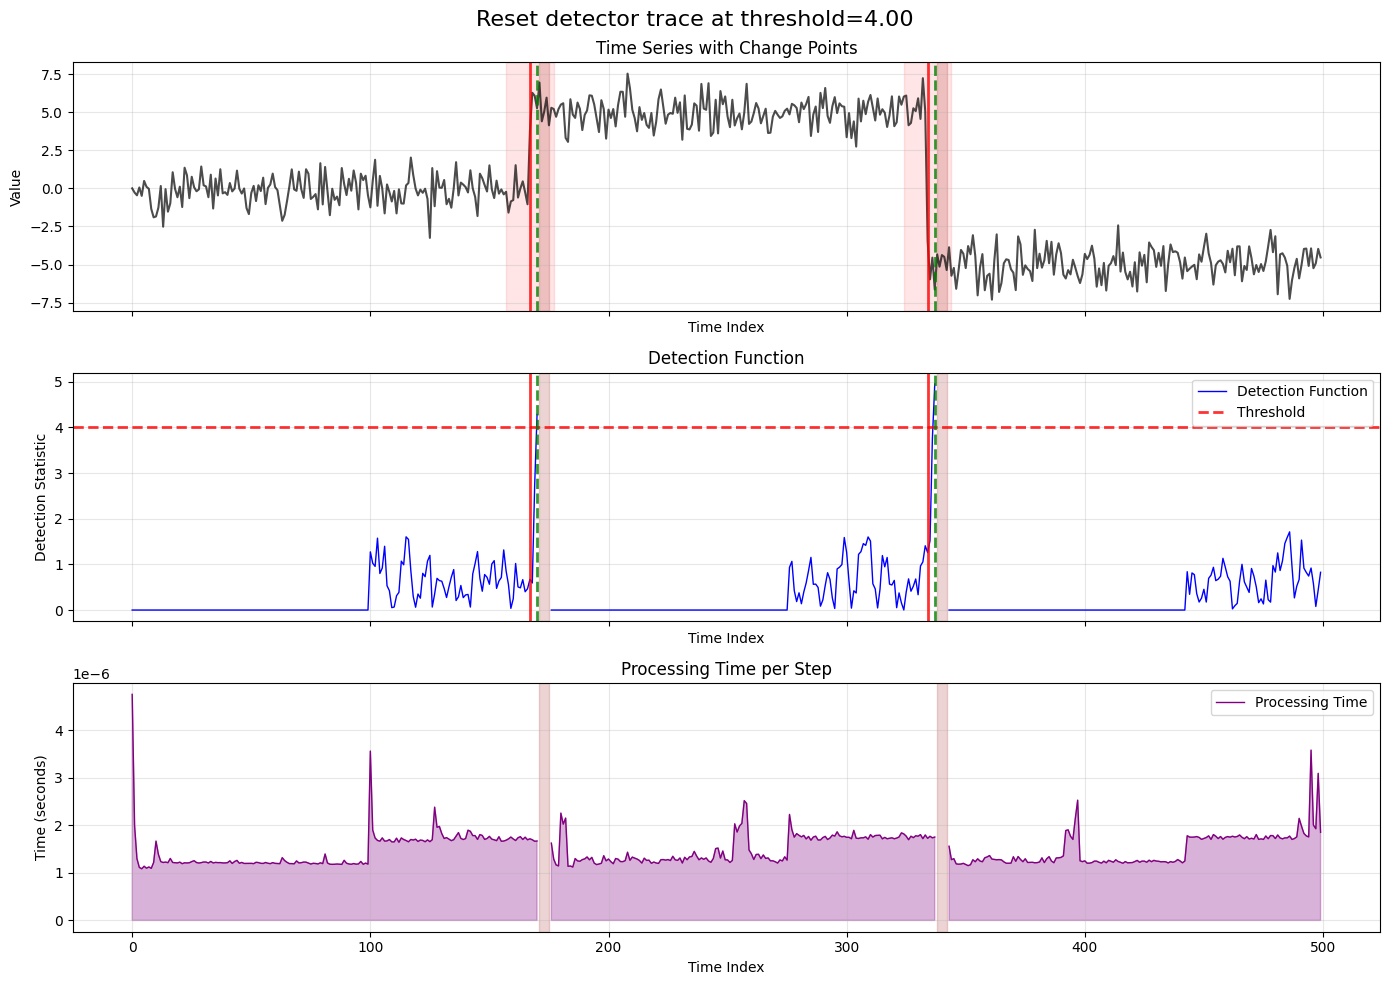

In [20]:
plotter = OnlineCpdPlotter(
    backend=DrawBackend.MATPLOTLIB,
    data_provider=transformed_provider,
    detection_trace=inspection_trace,
)
plotter.set_ground_truth(list(provider.change_points), margin=10)
plotter.set_legend_axis("detection_function")
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle(f"Reset detector trace at threshold={best_threshold:.2f}", fontsize=16)
fig = plotter.draw(
    figure=fig,
    axes={"timeseries": axes[0], "detection_function": axes[1], "processing_time": axes[2]},
)
plt.tight_layout()
fig.show()

**Summary of Section 7:** A reset benchmark result becomes much easier to trust once it is connected back to one concrete trace. The table tells us which threshold looks strong globally, and the trace helps explain what that operating point actually looks like on a real series.


## Section 8. Final Recap

This chapter built a full reset benchmark workflow around the current API. We created a detector sweep, separated execution orchestration from metric semantics, combined several metric families into one threshold-indexed table, visualized the resulting tradeoffs, and tied one selected operating point back to a concrete trace.

That is the reset benchmark story in PySATL-CPD. The next chapter changes the evaluation semantics entirely: no-reset benchmarking keeps the detector running continuously and shifts attention from whole-timeseries event sequences toward transition-aware classification and ARL-by-state analysis.
